In [59]:
!python -V

Python 3.12.13


In [60]:
import pandas as pd

In [61]:
import pickle

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

In [63]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

from sklearn.metrics import root_mean_squared_error

Se utilizo data de taxis
https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

Data dictionary
https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_green.pdf

In [64]:
#df = pd.read_parquet('./data/green_tripdata_2021-01.parquet')
df = pd.read_parquet(
    #"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"
    "https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2021-01.parquet"
)

In [65]:
# df2 = pd.read_parquet(
#     "https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2021-02.parquet"
# )

In [66]:
df.head(3)

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,2,2021-01-01 00:15:56,2021-01-01 00:19:52,N,1.0,43,151,1.0,1.01,5.5,0.5,0.5,0.00,0.0,None,0.3,6.80,2.0,1.0,0.00
1,2,2021-01-01 00:25:59,2021-01-01 00:34:44,N,1.0,166,239,1.0,2.53,10.0,0.5,0.5,2.81,0.0,None,0.3,16.86,1.0,1.0,2.75
2,2,2021-01-01 00:45:57,2021-01-01 00:51:55,N,1.0,41,42,1.0,1.12,6.0,0.5,0.5,1.00,0.0,None,0.3,8.30,1.0,1.0,0.00


In [67]:
df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
df.duration = df.duration.apply(lambda td: td.total_seconds() / 60) # Duration in minutes

In [80]:
df.duration.describe( percentiles=[0.25, 0.50, 0.75, 0.9, 0.95, 0.98, 0.99])

count    73908.000000
mean        16.852578
std         11.563163
min          1.000000
25%          8.050000
50%         14.000000
75%         22.633333
90%         34.000000
95%         41.000000
98%         48.781000
99%         53.000000
max         60.000000
Name: duration, dtype: float64

In [68]:
df.dtypes

VendorID                          int64
lpep_pickup_datetime     datetime64[us]
lpep_dropoff_datetime    datetime64[us]
store_and_fwd_flag                  str
RatecodeID                      float64
PULocationID                      int64
DOLocationID                      int64
passenger_count                 float64
trip_distance                   float64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
ehail_fee                        object
improvement_surcharge           float64
total_amount                    float64
payment_type                    float64
trip_type                       float64
congestion_surcharge            float64
duration                        float64
dtype: object

In [70]:
df = df[(df.duration >= 1) & (df.duration <= 60)] # el 95% de los recorridos duran menos de 1 hora.

categorical = ['PULocationID', 'DOLocationID'] # zona de pickup y de dropoff del pasajero.
numerical = ['trip_distance']

df[categorical] = df[categorical].astype(str)

In [71]:
train_dicts = df[categorical + numerical].to_dict(orient='records')

In [73]:
train_dicts

[{'PULocationID': '43', 'DOLocationID': '151', 'trip_distance': 1.01},
 {'PULocationID': '166', 'DOLocationID': '239', 'trip_distance': 2.53},
 {'PULocationID': '41', 'DOLocationID': '42', 'trip_distance': 1.12},
 {'PULocationID': '168', 'DOLocationID': '75', 'trip_distance': 1.99},
 {'PULocationID': '75', 'DOLocationID': '75', 'trip_distance': 0.45},
 {'PULocationID': '225', 'DOLocationID': '265', 'trip_distance': 12.19},
 {'PULocationID': '244', 'DOLocationID': '244', 'trip_distance': 3.39},
 {'PULocationID': '75', 'DOLocationID': '213', 'trip_distance': 6.69},
 {'PULocationID': '74', 'DOLocationID': '238', 'trip_distance': 2.34},
 {'PULocationID': '74', 'DOLocationID': '60', 'trip_distance': 5.48},
 {'PULocationID': '42', 'DOLocationID': '41', 'trip_distance': 0.9},
 {'PULocationID': '74', 'DOLocationID': '116', 'trip_distance': 2.08},
 {'PULocationID': '116', 'DOLocationID': '143', 'trip_distance': 4.64},
 {'PULocationID': '75', 'DOLocationID': '42', 'trip_distance': 1.68},
 {'PULo

In [72]:
dv = DictVectorizer()
print(dv)

DictVectorizer()


In [74]:
X_train = dv.fit_transform(train_dicts)
X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 221724 stored elements and shape (73908, 507)>

In [76]:
target = 'duration'
y_train = df[target].values
y_train

array([ 3.93333333,  8.75      ,  5.96666667, ..., 11.        ,
       27.        , 10.        ], shape=(73908,))

In [77]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_train)
y_pred

array([ 7.66699186, 13.74297417,  8.40093659, ..., 14.10827363,
       17.00908778, 19.87761884], shape=(73908,))

In [78]:
root_mean_squared_error(y_train, y_pred) # 9 minutos de error en promedio

9.838799799829626

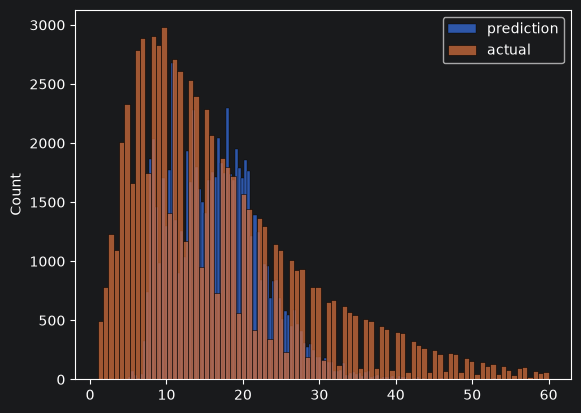

In [79]:
sns.histplot(y_pred, label='prediction')
sns.histplot(y_train, label='actual')

plt.legend()

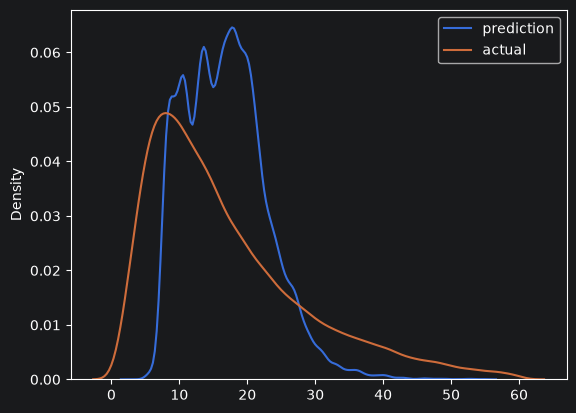

In [57]:
sns.kdeplot(y_pred, label='prediction')
sns.kdeplot(y_train, label='actual')

plt.legend()

In [81]:
def read_dataframe(filename):
    if filename.endswith('.csv'):
        df = pd.read_csv(filename)

        df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
        df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)
    elif filename.endswith('.parquet'):
        df = pd.read_parquet(filename)

    df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
    df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)
    
    return df

In [10]:
# df_train = read_dataframe('./data/green_tripdata_2021-01.parquet')
# df_val = read_dataframe('./data/green_tripdata_2021-02.parquet')

In [82]:
df_train = read_dataframe("https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2021-01.parquet")
df_val = read_dataframe("https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2021-02.parquet")

In [83]:
len(df_train), len(df_val)

(73908, 61921)

In [85]:
df_train['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID']

In [86]:
categorical = ['PU_DO'] #'PULocationID', 'DOLocationID']
numerical = ['trip_distance']

dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [87]:
target = 'duration'
y_train = df_train[target].values
y_val = df_val[target].values

In [88]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

root_mean_squared_error(y_val, y_pred)

7.758715210601492

In [16]:
# Save model
with open('models/lin_reg.bin', 'wb') as f_out:
    pickle.dump((dv, lr), f_out) # dict vectorizer y el modelo.

In [96]:
import numpy as np
X_train_lasso = X_train.tocsc()
X_val_lasso = X_val.tocsc()

X_train_lasso.indices = X_train_lasso.indices.astype(np.int32)
X_train_lasso.indptr = X_train_lasso.indptr.astype(np.int32)

X_val_lasso.indices = X_val_lasso.indices.astype(np.int32)
X_val_lasso.indptr = X_val_lasso.indptr.astype(np.int32)

In [100]:
lr = Lasso(alpha=0.001)
lr.fit(X_train_lasso, y_train)

y_pred = lr.predict(X_val_lasso)

In [101]:
rmse = root_mean_squared_error(y_val, y_pred)
rmse

9.23343622815571

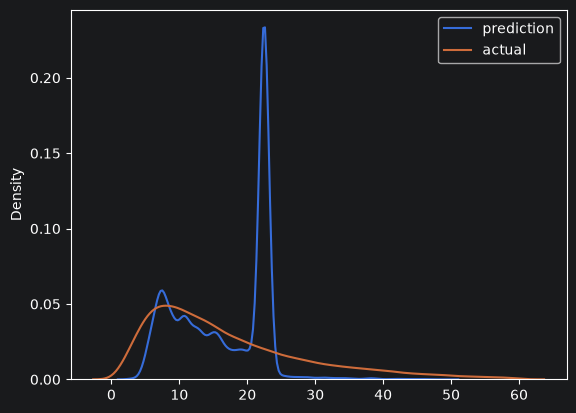

In [102]:
sns.kdeplot(y_pred, label='prediction')
sns.kdeplot(y_train, label='actual')

plt.legend()
